# 05 Regularized Regression Models

This notebook develops regularized regression models for predicting **Heating Load** and **Cooling Load** using the train-test splits saved from the previous modeling notebook. The purpose of this stage is to address the severe multicollinearity identified in the OLS models and assess whether penalized regression improves model stability and predictive performance.

The models considered are:

1. Ridge Regression (L2 penalty)
2. LASSO Regression (L1 penalty)
3. Elastic Net Regression (combined L1 and L2 penalty)

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

## Load Saved Training and Testing Data

The train-test split created in the baseline modeling notebook is reused here to ensure fair model comparison. This means that all models are trained and evaluated on exactly the same observations.

In [2]:
# ============================================================
# 2. LOAD SAVED TRAINING AND TESTING DATA
# ============================================================

DATA_DIR = Path("../data/modeling")

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")

y_heat_train = pd.read_csv(DATA_DIR / "y_heat_train.csv")["heating_load"]
y_heat_test = pd.read_csv(DATA_DIR / "y_heat_test.csv")["heating_load"]

y_cool_train = pd.read_csv(DATA_DIR / "y_cool_train.csv")["cooling_load"]
y_cool_test = pd.read_csv(DATA_DIR / "y_cool_test.csv")["cooling_load"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Heating train shape:", y_heat_train.shape)
print("Cooling train shape:", y_cool_train.shape)

display(X_train.head())

X_train shape: (614, 8)
X_test shape: (154, 8)
Heating train shape: (614,)
Cooling train shape: (614,)


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,0.82,612.5,318.5,147.0,7.0,2,0.10,1
1,0.64,784.0,343.0,220.5,3.5,4,0.40,2
2,0.86,588.0,294.0,147.0,7.0,4,0.25,2
3,0.90,563.5,318.5,122.5,7.0,4,0.25,1
4,0.66,759.5,318.5,220.5,3.5,5,0.10,4


In [3]:
# ============================================================
# 3. IDENTIFY FEATURE TYPES
# ============================================================

categorical_features = [
    "orientation",
    "glazing_area_distribution"
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area']
Categorical features: ['orientation', 'glazing_area_distribution']


## Preprocessing Strategy

Regularized regression models are sensitive to the scale of predictors because the penalty is applied to model coefficients. Therefore, numerical predictors are standardized, while categorical predictors are converted into dummy variables.

In [4]:
# ============================================================
# 4. PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)

In [5]:
# ============================================================
# 5. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, target_name, model_name):
    """Fit model and return train/test performance metrics."""

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    n_test = X_test.shape[0]
    # number of transformed predictors after preprocessing
    try:
        p = len(model.named_steps["preprocessor"].get_feature_names_out())
    except Exception:
        p = X_test.shape[1]

    test_r2 = r2_score(y_test, test_pred)
    adjusted_r2 = 1 - ((1 - test_r2) * (n_test - 1) / (n_test - p - 1))

    results = pd.DataFrame({
        "Target": [target_name],
        "Model": [model_name],
        "Train_R2": [r2_score(y_train, train_pred)],
        "Test_R2": [test_r2],
        "Test_Adjusted_R2": [adjusted_r2],
        "Test_RMSE": [np.sqrt(mean_squared_error(y_test, test_pred))],
        "Test_MAE": [mean_absolute_error(y_test, test_pred)]
    })

    return results, train_pred, test_pred, model

In [6]:
# ============================================================
# 6. CROSS-VALIDATION SETUP
# ============================================================

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

alphas = np.logspace(-4, 4, 200)

l1_ratios = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

# Ridge Regression

Ridge Regression applies an L2 penalty to shrink coefficients toward zero without necessarily eliminating predictors. It is especially useful when predictors are highly correlated, as observed among the building geometry variables.

In [7]:
# ============================================================
# 7. RIDGE REGRESSION MODELS
# ============================================================

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RidgeCV(alphas=alphas, cv=cv, scoring="neg_root_mean_squared_error"))
    ]
)

heat_ridge_results, heat_ridge_train_pred, heat_ridge_test_pred, heat_ridge_model = evaluate_model(
    ridge_pipeline,
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load",
    model_name="Ridge Regression"
)

cool_ridge_results, cool_ridge_train_pred, cool_ridge_test_pred, cool_ridge_model = evaluate_model(
    ridge_pipeline,
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load",
    model_name="Ridge Regression"
)

ridge_results = pd.concat([heat_ridge_results, cool_ridge_results], ignore_index=True)
display(ridge_results)

print("Best alpha for Heating Ridge:", heat_ridge_model.named_steps["model"].alpha_)
print("Best alpha for Cooling Ridge:", cool_ridge_model.named_steps["model"].alpha_)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
0,Heating Load,Ridge Regression,0.924138,0.920516,0.912510,2.878341,2.064123
1,Cooling Load,Ridge Regression,0.888174,0.894529,0.883906,3.126126,2.180461


Best alpha for Heating Ridge: 0.5478901179593945
Best alpha for Cooling Ridge: 0.5478901179593945


# LASSO Regression

LASSO Regression applies an L1 penalty, which can shrink some coefficients exactly to zero. This makes it useful for feature selection, especially when the aim is to identify a smaller subset of important predictors.

In [8]:
# ============================================================
# 8. LASSO REGRESSION MODELS
# ============================================================

lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LassoCV(alphas=alphas, cv=cv, max_iter=100000, random_state=42))
    ]
)

heat_lasso_results, heat_lasso_train_pred, heat_lasso_test_pred, heat_lasso_model = evaluate_model(
    lasso_pipeline,
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load",
    model_name="LASSO Regression"
)

cool_lasso_results, cool_lasso_train_pred, cool_lasso_test_pred, cool_lasso_model = evaluate_model(
    lasso_pipeline,
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load",
    model_name="LASSO Regression"
)

lasso_results = pd.concat([heat_lasso_results, cool_lasso_results], ignore_index=True)
display(lasso_results)

print("Best alpha for Heating LASSO:", heat_lasso_model.named_steps["model"].alpha_)
print("Best alpha for Cooling LASSO:", cool_lasso_model.named_steps["model"].alpha_)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
0,Heating Load,LASSO Regression,0.924132,0.920532,0.912528,2.878039,2.062852
1,Cooling Load,LASSO Regression,0.888211,0.894600,0.883984,3.125076,2.179070


Best alpha for Heating LASSO: 0.0023272024789604074
Best alpha for Cooling LASSO: 0.0023272024789604074


# Elastic Net Regression

Elastic Net combines the L1 penalty of LASSO and the L2 penalty of Ridge Regression. It is particularly useful when predictors are highly correlated because it can perform variable selection while also stabilizing coefficient estimates.

In [9]:
# ============================================================
# 9. ELASTIC NET REGRESSION MODELS
# ============================================================

elastic_net_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ElasticNetCV(
            alphas=alphas,
            l1_ratio=l1_ratios,
            cv=cv,
            max_iter=100000,
            random_state=42
        ))
    ]
)

heat_enet_results, heat_enet_train_pred, heat_enet_test_pred, heat_enet_model = evaluate_model(
    elastic_net_pipeline,
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load",
    model_name="Elastic Net Regression"
)

cool_enet_results, cool_enet_train_pred, cool_enet_test_pred, cool_enet_model = evaluate_model(
    elastic_net_pipeline,
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load",
    model_name="Elastic Net Regression"
)

enet_results = pd.concat([heat_enet_results, cool_enet_results], ignore_index=True)
display(enet_results)

print("Best alpha for Heating Elastic Net:", heat_enet_model.named_steps["model"].alpha_)
print("Best l1_ratio for Heating Elastic Net:", heat_enet_model.named_steps["model"].l1_ratio_)
print("Best alpha for Cooling Elastic Net:", cool_enet_model.named_steps["model"].alpha_)
print("Best l1_ratio for Cooling Elastic Net:", cool_enet_model.named_steps["model"].l1_ratio_)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
0,Heating Load,Elastic Net Regression,0.924135,0.920551,0.912549,2.877706,2.062607
1,Cooling Load,Elastic Net Regression,0.888202,0.894576,0.883958,3.125425,2.178830


Best alpha for Heating Elastic Net: 0.00212145178491063
Best l1_ratio for Heating Elastic Net: 0.9
Best alpha for Cooling Elastic Net: 0.00212145178491063
Best l1_ratio for Cooling Elastic Net: 0.9


# Coefficient Analysis

The coefficient tables below show how each regularized model weights the predictors after preprocessing. Since numerical variables were standardized, coefficient magnitudes are more comparable than in unscaled OLS models.

In [10]:
# ============================================================
# 10. EXTRACT FEATURE NAMES AND COEFFICIENTS
# ============================================================

def coefficient_table(fitted_pipeline, target_name, model_name):
    feature_names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefficients = fitted_pipeline.named_steps["model"].coef_

    table = pd.DataFrame({
        "Target": target_name,
        "Model": model_name,
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Absolute_Coefficient": np.abs(coefficients)
    }).sort_values("Absolute_Coefficient", ascending=False)

    return table

coef_tables = pd.concat([
    coefficient_table(heat_ridge_model, "Heating Load", "Ridge Regression"),
    coefficient_table(cool_ridge_model, "Cooling Load", "Ridge Regression"),
    coefficient_table(heat_lasso_model, "Heating Load", "LASSO Regression"),
    coefficient_table(cool_lasso_model, "Cooling Load", "LASSO Regression"),
    coefficient_table(heat_enet_model, "Heating Load", "Elastic Net Regression"),
    coefficient_table(cool_enet_model, "Cooling Load", "Elastic Net Regression"),
], ignore_index=True)

display(coef_tables.head(30))

,Target,Model,Feature,Coefficient,Absolute_Coefficient
0,Heating Load,Ridge Regression,num__overall_height,7.350619,7.350619
1,Heating Load,Ridge Regression,num__relative_compactness,-6.649678,6.649678
2,Heating Load,Ridge Regression,num__roof_area,-3.608550,3.608550
3,Heating Load,Ridge Regression,num__surface_area,-3.549547,3.549547
4,Heating Load,Ridge Regression,num__glazing_area,1.829552,1.829552
5,Heating Load,Ridge Regression,cat__glazing_area_distribution_2,1.690461,1.690461
6,Heating Load,Ridge Regression,cat__glazing_area_distribution_1,1.586793,1.586793
7,Heating Load,Ridge Regression,cat__glazing_area_distribution_3,1.518797,1.518797
8,Heating Load,Ridge Regression,cat__glazing_area_distribution_4,1.426212,1.426212
9,Heating Load,Ridge Regression,cat__glazing_area_distribution_5,1.295371,1.295371


In [11]:
# ============================================================
# 11. LASSO / ELASTIC NET SELECTED FEATURES
# ============================================================

selected_features = coef_tables[
    (coef_tables["Model"].isin(["LASSO Regression", "Elastic Net Regression"])) &
    (coef_tables["Coefficient"].abs() > 1e-6)
].sort_values(["Target", "Model", "Absolute_Coefficient"], ascending=[True, True, False])

display(selected_features)

,Target,Model,Feature,Coefficient,Absolute_Coefficient
70,Cooling Load,Elastic Net Regression,num__overall_height,7.292719,7.292719
71,Cooling Load,Elastic Net Regression,num__relative_compactness,-6.951940,6.951940
72,Cooling Load,Elastic Net Regression,num__roof_area,-3.990739,3.990739
73,Cooling Load,Elastic Net Regression,num__surface_area,-3.530415,3.530415
74,Cooling Load,Elastic Net Regression,num__glazing_area,1.837656,1.837656
75,Cooling Load,Elastic Net Regression,cat__glazing_area_distribution_2,1.603439,1.603439
76,Cooling Load,Elastic Net Regression,cat__glazing_area_distribution_1,1.500176,1.500176
77,Cooling Load,Elastic Net Regression,cat__glazing_area_distribution_3,1.431551,1.431551
78,Cooling Load,Elastic Net Regression,cat__glazing_area_distribution_4,1.339251,1.339251
79,Cooling Load,Elastic Net Regression,cat__glazing_area_distribution_5,1.206104,1.206104


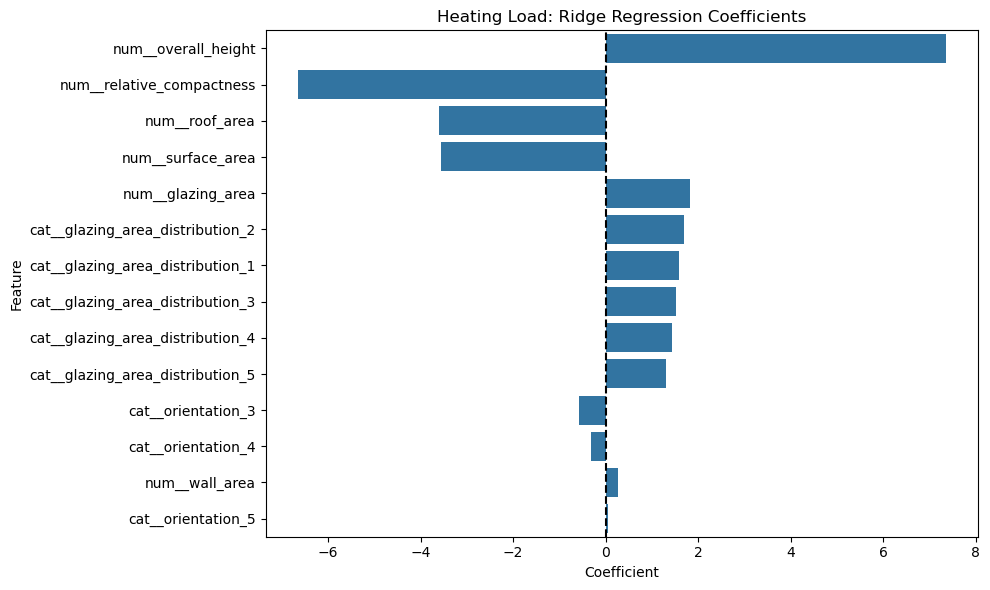

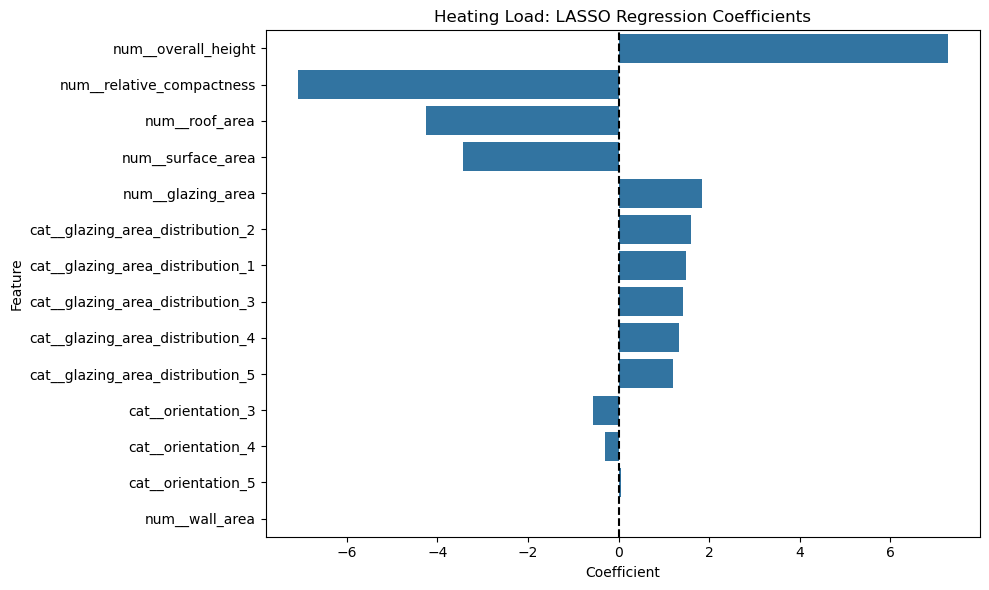

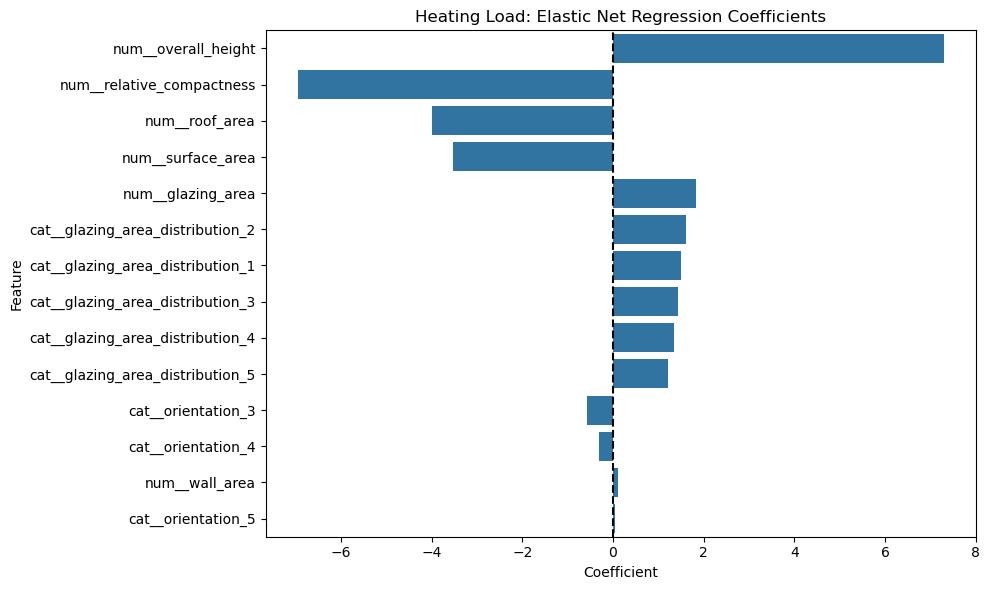

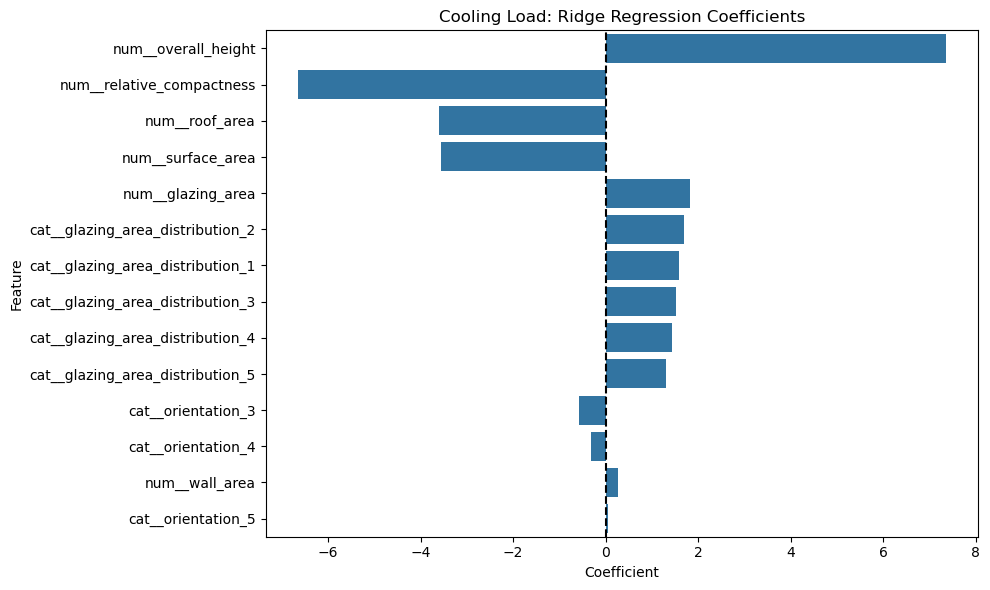

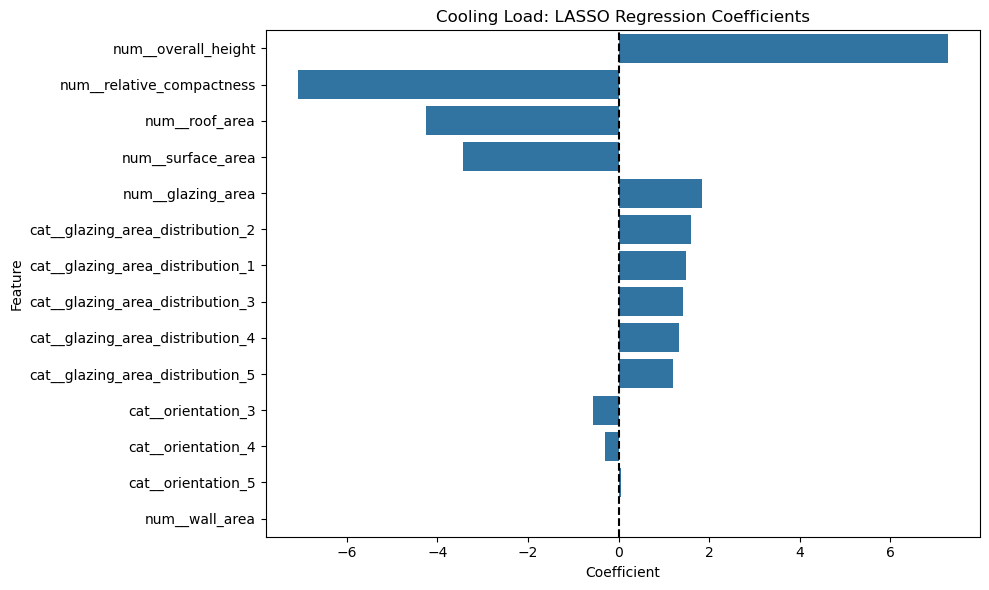

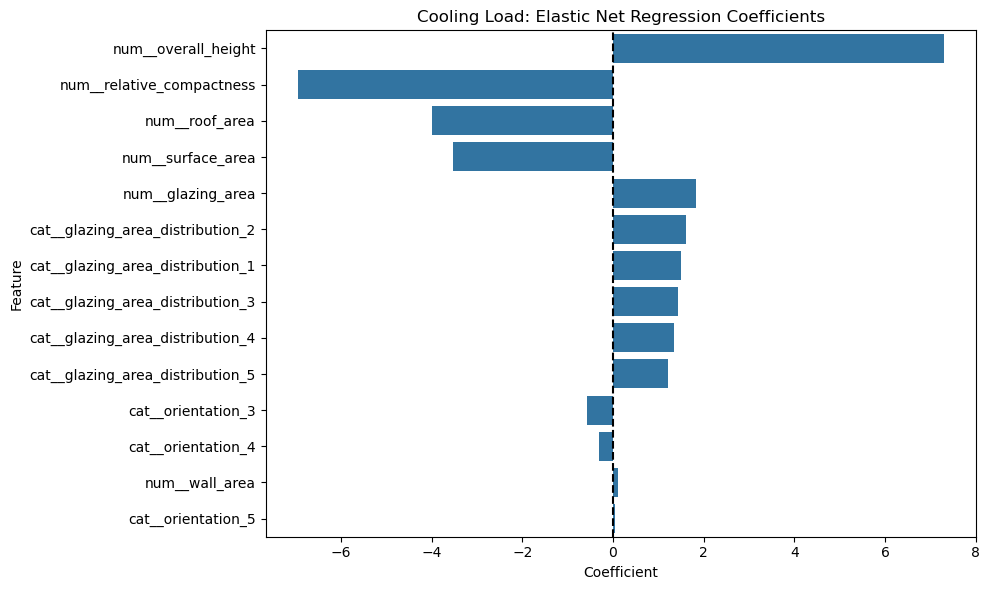

In [12]:
# ============================================================
# 12. COEFFICIENT PLOTS
# ============================================================

def plot_coefficients(coef_df, target_name, model_name, top_n=15):
    plot_df = coef_df[
        (coef_df["Target"] == target_name) &
        (coef_df["Model"] == model_name)
    ].copy()

    plot_df = plot_df.sort_values("Absolute_Coefficient", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=plot_df,
        x="Coefficient",
        y="Feature"
    )
    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"{target_name}: {model_name} Coefficients")
    plt.tight_layout()
    plt.show()

for target in ["Heating Load", "Cooling Load"]:
    for model in ["Ridge Regression", "LASSO Regression", "Elastic Net Regression"]:
        plot_coefficients(coef_tables, target, model)

# Prediction Diagnostics

The following plots compare observed and predicted values for the regularized models on the test set. Strong models should show points close to the diagonal reference line.

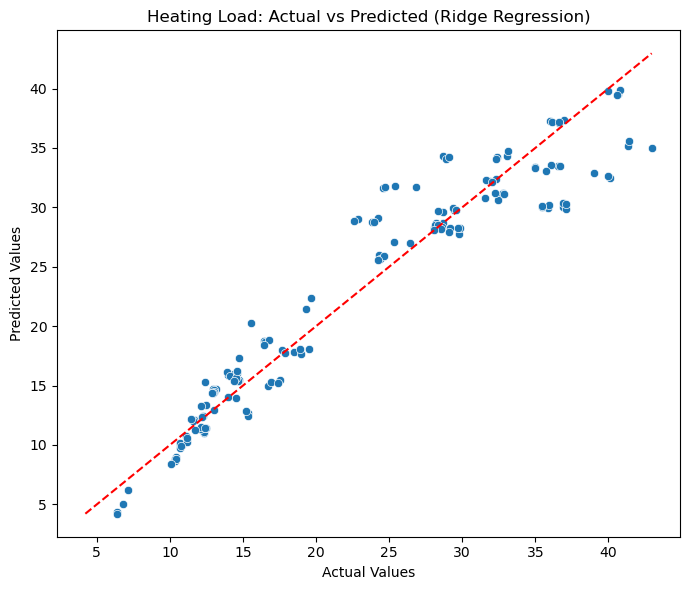

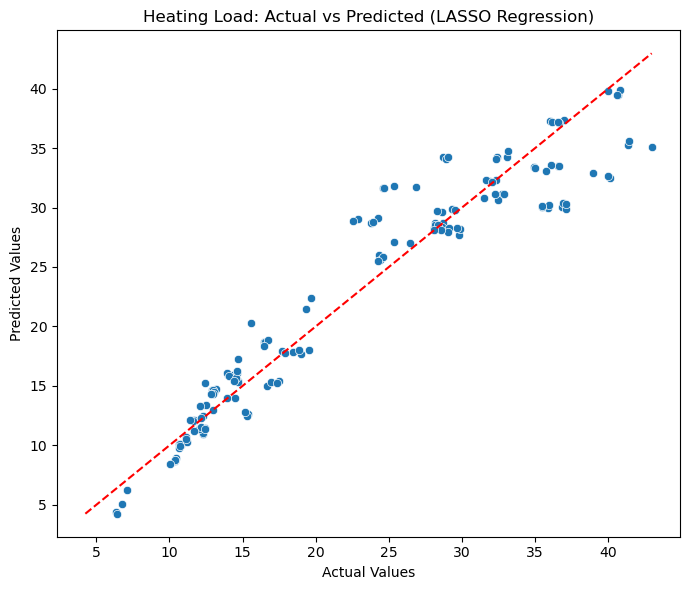

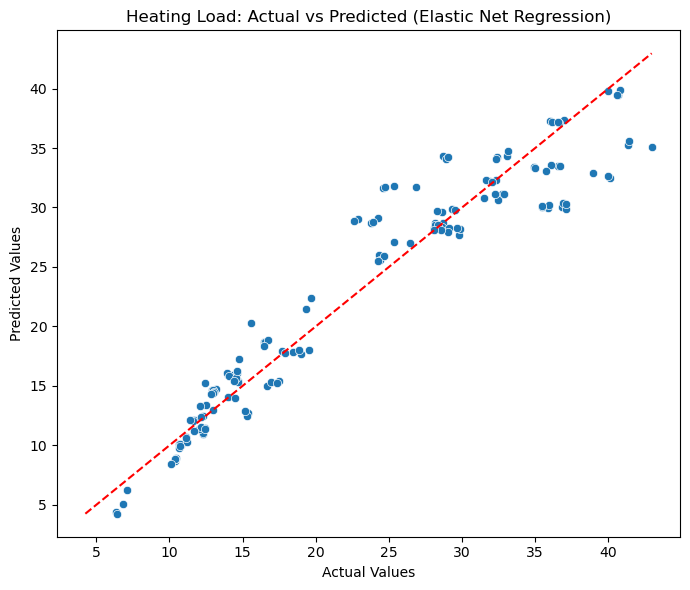

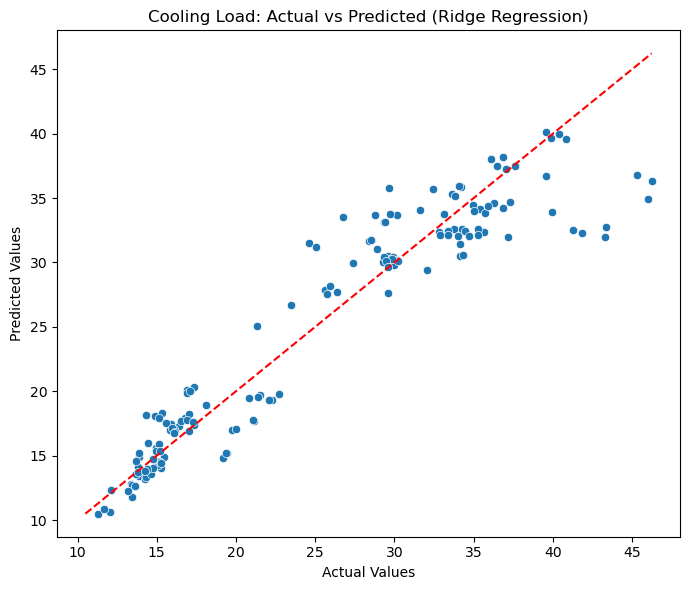

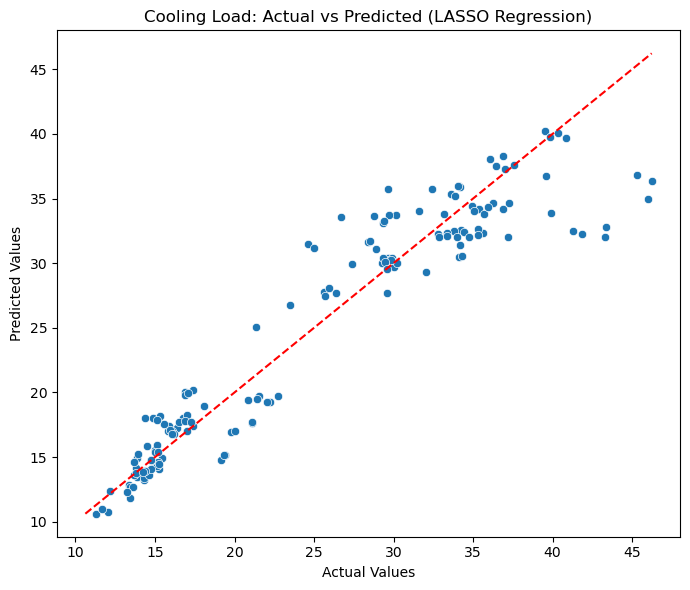

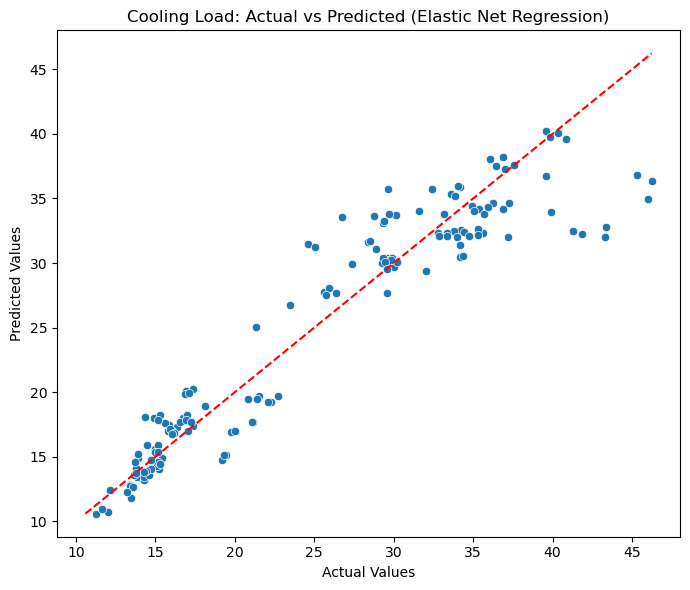

In [13]:
# ============================================================
# 13. ACTUAL VS PREDICTED PLOTS
# ============================================================

def actual_vs_predicted_plot(y_true, y_pred, target_name, model_name):
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_true, y=y_pred)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{target_name}: Actual vs Predicted ({model_name})")
    plt.tight_layout()
    plt.show()

prediction_sets = [
    (y_heat_test, heat_ridge_test_pred, "Heating Load", "Ridge Regression"),
    (y_heat_test, heat_lasso_test_pred, "Heating Load", "LASSO Regression"),
    (y_heat_test, heat_enet_test_pred, "Heating Load", "Elastic Net Regression"),
    (y_cool_test, cool_ridge_test_pred, "Cooling Load", "Ridge Regression"),
    (y_cool_test, cool_lasso_test_pred, "Cooling Load", "LASSO Regression"),
    (y_cool_test, cool_enet_test_pred, "Cooling Load", "Elastic Net Regression"),
]

for y_true, y_pred, target, model in prediction_sets:
    actual_vs_predicted_plot(y_true, y_pred, target, model)

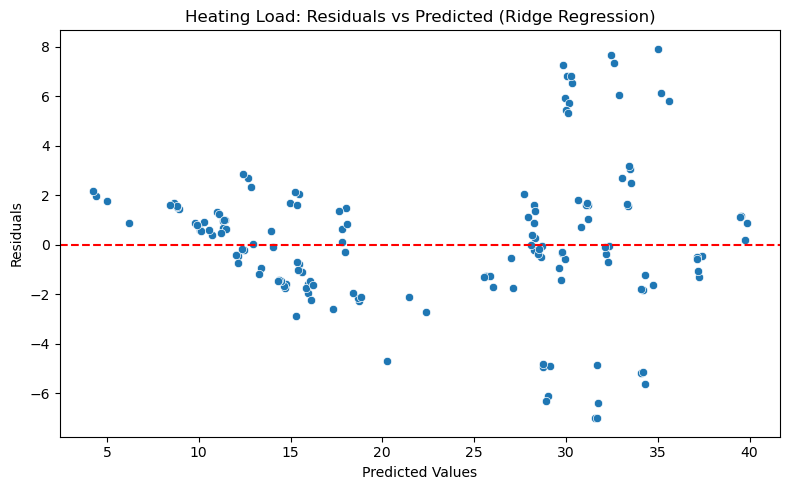

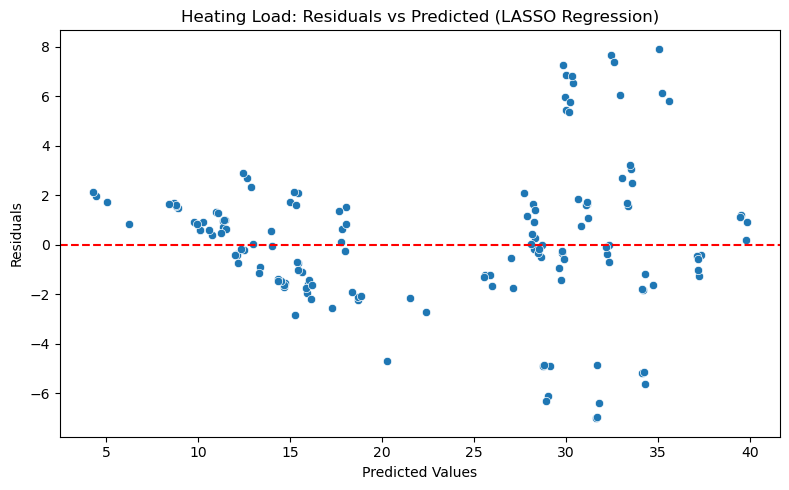

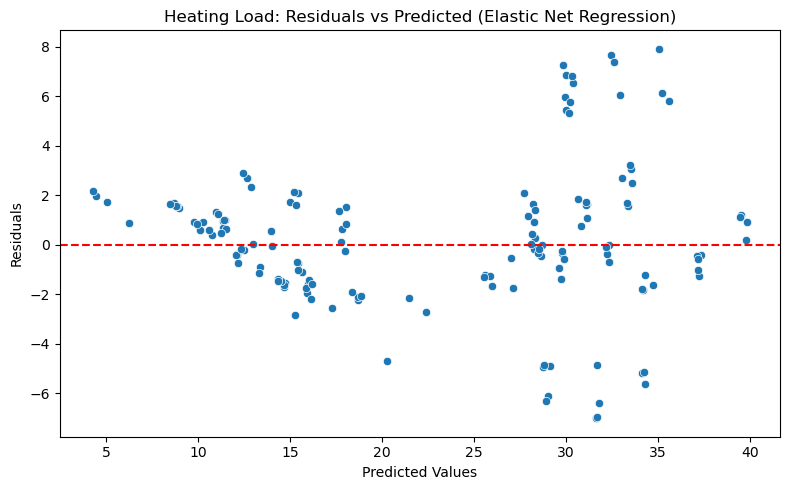

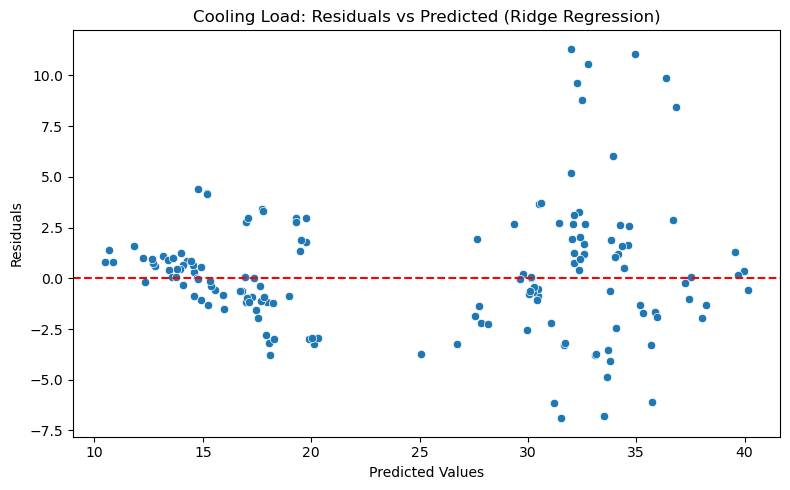

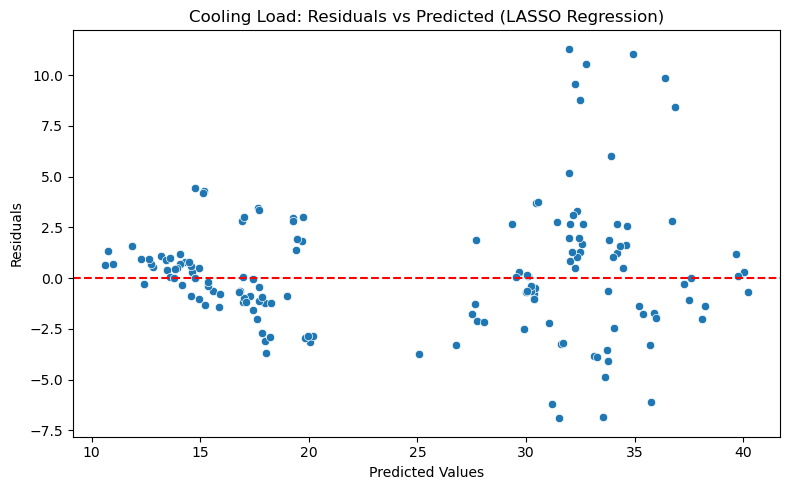

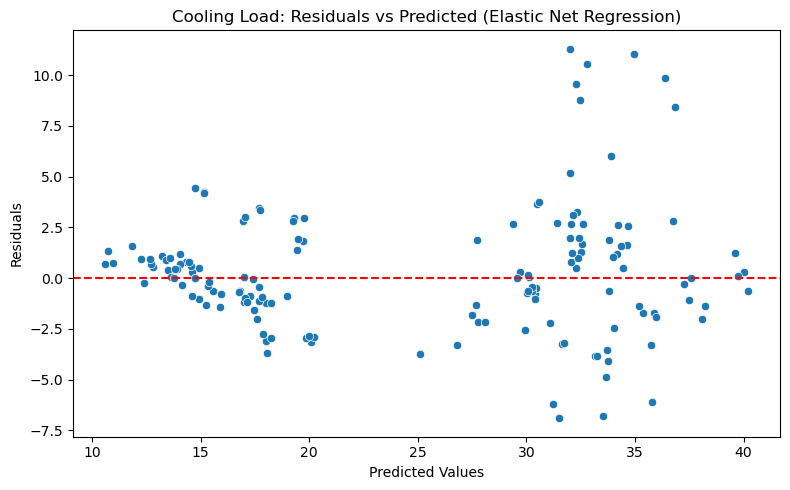

In [14]:
# ============================================================
# 14. RESIDUAL PLOTS
# ============================================================

def residual_plot(y_true, y_pred, target_name, model_name):
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{target_name}: Residuals vs Predicted ({model_name})")
    plt.tight_layout()
    plt.show()

for y_true, y_pred, target, model in prediction_sets:
    residual_plot(y_true, y_pred, target, model)

# Model Comparison

This section compares the regularized regression models for both Heating Load and Cooling Load. The best model is selected primarily based on test RMSE and test R².

In [15]:
# ============================================================
# 15. COMBINE RESULTS
# ============================================================

regularized_results = pd.concat(
    [ridge_results, lasso_results, enet_results],
    ignore_index=True
)

regularized_results = regularized_results.sort_values(
    by=["Target", "Test_RMSE"],
    ascending=[True, True]
)

display(regularized_results)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
3,Cooling Load,LASSO Regression,0.888211,0.894600,0.883984,3.125076,2.179070
5,Cooling Load,Elastic Net Regression,0.888202,0.894576,0.883958,3.125425,2.178830
1,Cooling Load,Ridge Regression,0.888174,0.894529,0.883906,3.126126,2.180461
4,Heating Load,Elastic Net Regression,0.924135,0.920551,0.912549,2.877706,2.062607
2,Heating Load,LASSO Regression,0.924132,0.920532,0.912528,2.878039,2.062852
0,Heating Load,Ridge Regression,0.924138,0.920516,0.912510,2.878341,2.064123


### Regularized Regression Model Performance Summary

The regularized regression models demonstrated predictive performance that was remarkably similar across Ridge, LASSO, and Elastic Net for both Heating Load and Cooling Load. For Heating Load, all three methods achieved test \(R^2\) values of approximately **0.921**, while for Cooling Load the test \(R^2\) values were approximately **0.895**, indicating that the models retained strong explanatory and predictive capability. The small differences between training and testing \(R^2\) values suggest good generalization performance and little evidence of overfitting.

Among the Cooling Load models, **LASSO Regression** achieved the best overall performance with the highest test \(R^2\) (0.8946) and the lowest RMSE (3.1251), although the improvement over Ridge and Elastic Net was marginal. Similarly, for Heating Load, **Elastic Net Regression** achieved the highest test \(R^2\) (0.9206) and the lowest RMSE (2.8777), but the performance differences among the three methods were negligible. Overall, the results indicate that regularization successfully stabilized the regression models and addressed multicollinearity concerns without sacrificing predictive accuracy, while confirming that the underlying relationships in the dataset are already captured effectively by a relatively simple linear structure.

In [16]:
# ============================================================
# 16. BEST REGULARIZED MODEL PER TARGET
# ============================================================

best_regularized_models = (
    regularized_results
    .sort_values(["Target", "Test_RMSE"], ascending=[True, True])
    .groupby("Target")
    .head(1)
    .reset_index(drop=True)
)

display(best_regularized_models)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
0,Cooling Load,LASSO Regression,0.888211,0.894600,0.883984,3.125076,2.179070
1,Heating Load,Elastic Net Regression,0.924135,0.920551,0.912549,2.877706,2.062607


In [17]:
# ============================================================
# 17. SAVE REGULARIZED MODEL RESULTS
# ============================================================

OUTPUT_DIR = Path("../outputs/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

regularized_results.to_csv(
    OUTPUT_DIR / "regularized_regression_results.csv",
    index=False
)

best_regularized_models.to_csv(
    OUTPUT_DIR / "best_regularized_models.csv",
    index=False
)

coef_tables.to_csv(
    OUTPUT_DIR / "regularized_regression_coefficients.csv",
    index=False
)

selected_features.to_csv(
    OUTPUT_DIR / "regularized_selected_features.csv",
    index=False
)

print("Regularized regression outputs saved successfully to:", OUTPUT_DIR.resolve())

Regularized regression outputs saved successfully to: C:\Users\admin\Desktop\pppp lab\group-work\outputs\models


# Regularized Regression Summary

Ridge, LASSO, and Elastic Net regression models were fitted to address the severe multicollinearity identified in the baseline and parametric OLS models. Across both Heating Load and Cooling Load prediction tasks, the three regularization approaches produced remarkably similar results, indicating that the predictive information contained within the building characteristics is highly stable. For Heating Load, the best-performing model was **Elastic Net Regression**, achieving a test \(R^2\) of **0.9206**, an adjusted \(R^2\) of **0.9125**, an RMSE of **2.8777**, and an MAE of **2.0626**. For Cooling Load, **LASSO Regression** achieved the highest test \(R^2\) of **0.8946**, with an RMSE of **3.1251** and an MAE of **2.1791**, although its advantage over Ridge and Elastic Net was negligible.

The close agreement between training and testing \(R^2\) values across all models suggests excellent generalization performance and little evidence of overfitting. Furthermore, the regularized models achieved predictive performance that was nearly identical to the optimized parametric OLS models, indicating that regularization successfully stabilized coefficient estimation without substantially altering predictive accuracy. This finding suggests that while multicollinearity was present, it was not severely affecting predictive performance, although it may still impact coefficient interpretation.

Overall, the regularized regression models confirm that the relationship between building design characteristics and energy loads can be effectively captured using linear modeling approaches. However, the performance improvements over the optimized OLS models were minimal, suggesting that the primary limitation of the current models is not multicollinearity but rather the presence of nonlinear relationships identified earlier through the Ramsey RESET tests. Consequently, the next stage of the analysis should focus on **semi-parametric and nonlinear modeling approaches**, particularly **Generalized Additive Models (GAMs)**, to determine whether modeling nonlinear effects can provide additional predictive improvements beyond those achieved by linear and regularized regression methods.